In [61]:
import pandas as pd

In [62]:
df = pd.read_csv('original_dataset/wfp_food_prices_gha.csv')

In [67]:
sorted(df['commodity'].unique())

['Cassava',
 'Cowpeas',
 'Cowpeas (white)',
 'Eggplants',
 'Eggs',
 'Fish (mackerel, fresh)',
 'Gari',
 'Maize',
 'Maize (yellow)',
 'Meat (chicken)',
 'Meat (chicken, local)',
 'Millet',
 'Onions',
 'Peppers (dried)',
 'Peppers (fresh)',
 'Plantains (apem)',
 'Plantains (apentu)',
 'Rice (imported)',
 'Rice (local)',
 'Rice (paddy)',
 'Sorghum',
 'Soybeans',
 'Tomatoes (local)',
 'Tomatoes (navrongo)',
 'Yam',
 'Yam (puna)']

In [6]:
df.columns

Index(['date', 'region', 'city', 'market_sold_at', 'market_id', 'latitude',
       'longitude', 'commodity', 'category', 'commodity_id', 'unit',
       'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='object')

### Notes
    1. ARIMA is univariate, so we will use one independent variable (feature) and one dependent variable (target)
    2. Deal with one location at a time to be able to determine trends, seasonality, randomness, or cycles.

In [9]:
# Check for unique regions
df[['latitude', 'longitude']].nunique()

latitude     41
longitude    40
dtype: int64

In [16]:
# Group longitude by latitude
df.groupby(['latitude', 'longitude']).size()

latitude  longitude
4.93      -1.70        2519
5.11      -1.24        2092
5.27      -1.02        1509
5.55      -0.22        3244
5.62      -0.02        2017
6.08      -0.25        1854
6.20      -1.67        1487
6.60       0.47        1398
6.68      -1.62        3243
7.15       0.47        1203
7.33      -2.33        2459
7.38      -1.37        1431
7.53       0.47           4
7.58      -1.93        3262
7.69      -2.23           4
7.78      -0.23           4
7.80      -0.05           4
8.06      -1.73        1733
           0.18           4
8.22      -0.65           4
8.26       0.52         456
8.32      -0.13           4
8.47      -0.01           4
           0.36           4
8.85       0.06           4
9.30       0.37           4
9.40      -0.83        2948
9.45      -0.01         733
9.71       0.31           4
9.83      -2.68           3
9.92      -0.22           4
10.05     -2.48        1969
10.37     -2.66           4
10.45     -1.31           4
10.51      0.10           3


In [31]:
apentu = df[df['commodity'] == 'Plantains (apentu)']

In [39]:
apentu_retail = apentu[apentu['pricetype'] == 'Retail']

In [57]:
apentu_retail.sort_values(by=['price'], ascending=False).head(20)

,date,region,city,market_sold_at,market_id,latitude,longitude,commodity,category,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
19337,15/07/2020,GREATER ACCRA,Tema,TEMA METROPOLIS,210,5.62,-0.02,Plantains (apentu),vegetables and fruits,98,KG,aggregate,Retail,GHS,55.56,9.75
30913,15/05/2022,GREATER ACCRA,Tema,TEMA METROPOLIS,210,5.62,-0.02,Plantains (apentu),vegetables and fruits,98,KG,aggregate,Retail,GHS,30.16,4.04
30319,15/04/2022,GREATER ACCRA,Tema,TEMA METROPOLIS,210,5.62,-0.02,Plantains (apentu),vegetables and fruits,98,KG,aggregate,Retail,GHS,30.16,4.05
31380,15/06/2022,GREATER ACCRA,Tema,TEMA METROPOLIS,210,5.62,-0.02,Plantains (apentu),vegetables and fruits,98,KG,aggregate,Retail,GHS,30.16,3.84
31843,15/07/2022,GREATER ACCRA,Tema,TEMA METROPOLIS,210,5.62,-0.02,Plantains (apentu),vegetables and fruits,98,KG,aggregate,Retail,GHS,30.16,3.78
29815,15/03/2022,GREATER ACCRA,Tema,TEMA METROPOLIS,210,5.62,-0.02,Plantains (apentu),vegetables and fruits,98,KG,aggregate,Retail,GHS,23.81,3.40
19053,15/07/2020,ASHANTI,Kumasi,KMA,215,6.68,-1.62,Plantains (apentu),vegetables and fruits,98,KG,aggregate,Retail,GHS,21.67,3.80
17716,15/04/2020,GREATER ACCRA,Tema,TEMA METROPOLIS,210,5.62,-0.02,Plantains (apentu),vegetables and fruits,98,KG,aggregate,Retail,GHS,18.89,3.31
32717,15/09/2022,CENTRAL,Cape Coast,CAPE COAST METRO,213,5.11,-1.24,Plantains (apentu),vegetables and fruits,98,KG,aggregate,Retail,GHS,18.89,1.91
18381,15/05/2020,GREATER ACCRA,Tema,TEMA METROPOLIS,210,5.62,-0.02,Plantains (apentu),vegetables and fruits,98,KG,aggregate,Retail,GHS,18.89,3.32


In [53]:
apentu_retail['price'].describe()

count    722.000000
mean       4.922438
std        4.157004
min        0.320000
25%        2.467500
50%        4.240000
75%        5.997500
max       55.560000
Name: price, dtype: float64

In [43]:
Len = 722

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

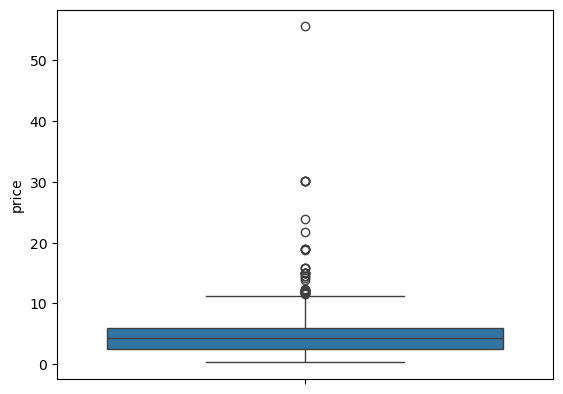

In [60]:
sns.boxplot(data=apentu_retail['price'])
plt.show()